# Construire un classificateur par arbre de décision

CSI 4506 — Introduction à l’intelligence artificielle

Marcel Turcotte  
2026-09-13

# Introduction

Ce cahier construit un petit classificateur par arbre de décision à
partir des principes fondamentaux. L’objectif n’est pas de concurrencer
scikit-learn, mais de rendre visibles les opérations centrales de
l’algorithme d’apprentissage :

1.  mesurer à quel point les classes d’un nœud sont mélangées;
2.  évaluer les divisions candidates;
3.  conserver la meilleure division;
4.  répéter le processus récursivement.

L’implémentation accepte des attributs numériques, des divisions
binaires par seuil, plusieurs classes, des prédictions de probabilités
et quelques conditions d’arrêt. Elle omet volontairement les valeurs
manquantes, les attributs catégoriels, les poids d’exemples, la
recherche optimisée des divisions et l’élagage.

# Préparation

La seule dépendance non standard est `palmerpenguins`. L’installation ne
s’exécute que si ce paquet est absent, ce qui permet d’utiliser le
cahier dans une nouvelle session Google Colab.

In [2]:
import subprocess
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

try:
    from palmerpenguins import load_penguins
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "palmerpenguins"
    ])
    from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split

# Manchots de Palmer

Nous conservons deux attributs numériques et formulons une tâche de
classification binaire : **Gentoo** ou **pas Gentoo**. Avec seulement
deux attributs, nous pouvons représenter les régions de décision
apprises.

In [3]:
feature_names = ["bill_depth_mm", "body_mass_g"]

penguins = load_penguins()
penguins = penguins[feature_names + ["species"]].dropna().copy()

X = penguins[feature_names].to_numpy()
y = np.where(
    penguins["species"].to_numpy() == "Gentoo",
    "Gentoo",
    "Pas Gentoo",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Exemples d'entraînement : {len(X_train)}")
print(f"Exemples de test : {len(X_test)}")

Exemples d'entraînement : 273
Exemples de test : 69

# Entropie

Pour un nœud dont les proportions des classes sont $p_1,\ldots,p_K$,
l’entropie est

$$
H=-\sum_{k=1}^{K}p_k\log_2p_k.
$$

Un nœud pur a une entropie nulle. L’entropie augmente lorsque les
proportions des classes deviennent plus équilibrées.

In [4]:
def class_probabilities(y, classes):
    """Retourner la proportion d'exemples de chaque classe."""
    return np.array([np.mean(y == label) for label in classes])


def entropy(y, classes):
    """Mesurer le mélange des classes; zéro correspond à un nœud pur."""
    probabilities = class_probabilities(y, classes)
    probabilities = probabilities[probabilities > 0]
    if len(probabilities) == 1:
        return 0.0
    return float(-np.sum(probabilities * np.log2(probabilities)))

Cette petite vérification retrouve les valeurs binaires familières : un
nœud équilibré possède un bit d’entropie, tandis qu’un nœud pur n’en
possède aucun.

In [5]:
binary_classes = np.array(["Gentoo", "Pas Gentoo"])

balanced = np.array(["Gentoo", "Pas Gentoo"])
pure = np.array(["Gentoo", "Gentoo"])

print(f"Nœud équilibré : {entropy(balanced, binary_classes):.3f} bit")
print(f"Nœud pur : {entropy(pure, binary_classes):.3f} bit")

Nœud équilibré : 1.000 bit
Nœud pur : 0.000 bit

# Évaluation d’une division

Une division candidate crée un enfant gauche et un enfant droit. Nous
l’évaluons au moyen de leur entropie pondérée :

$$
J=
\frac{N_{\mathrm{left}}}{N_{\mathrm{parent}}}H_{\mathrm{left}}
+
\frac{N_{\mathrm{right}}}{N_{\mathrm{parent}}}H_{\mathrm{right}}.
$$

La pondération empêche un minuscule enfant pur d’avoir autant
d’influence qu’un enfant beaucoup plus grand dont les classes sont
mélangées.

In [6]:
def weighted_entropy(y_left, y_right, classes):
    """Retourner l'entropie pondérée produite par une division."""
    n_left = len(y_left)
    n_right = len(y_right)
    n_parent = n_left + n_right

    return (
        n_left / n_parent * entropy(y_left, classes)
        + n_right / n_parent * entropy(y_right, classes)
    )


def candidate_thresholds(values):
    """Retourner les milieux entre les valeurs distinctes consécutives."""
    values = np.unique(values)
    return (values[:-1] + values[1:]) / 2

## Trois divisions candidates

L’exemple suivant compare les cas présentés en classe. Sans pondération,
isoler un seul exemple pur semble artificiellement avantageux.

In [7]:
split_examples = {
    "désordonnée": (
        np.array(["Gentoo"] * 3 + ["Pas Gentoo"] * 2),
        np.array(["Gentoo"] * 2 + ["Pas Gentoo"] * 3),
    ),
    "isole un": (
        np.array(["Gentoo"]),
        np.array(["Gentoo"] * 4 + ["Pas Gentoo"] * 5),
    ),
    "utile": (
        np.array(["Gentoo"] * 4 + ["Pas Gentoo"]),
        np.array(["Gentoo"] + ["Pas Gentoo"] * 4),
    ),
}

for name, (left, right) in split_examples.items():
    unweighted = (
        entropy(left, binary_classes) + entropy(right, binary_classes)
    ) / 2
    weighted = weighted_entropy(left, right, binary_classes)
    print(f"{name:>11} : non pondérée={unweighted:.3f}, pondérée={weighted:.3f}")

désordonnée : non pondérée=0.971, pondérée=0.971
   isole un : non pondérée=0.496, pondérée=0.892
      utile : non pondérée=0.722, pondérée=0.722

# Recherche gloutonne d’une division

Pour chaque attribut, nous examinons les milieux entre les valeurs
distinctes consécutives. La fonction conserve la division candidate dont
l’entropie pondérée est la plus faible.

In [8]:
def find_best_split(X, y, classes, min_samples_leaf):
    """Retourner la meilleure division et le nombre de candidates évaluées."""
    best_split = None
    best_score = entropy(y, classes)
    n_candidates = 0

    for feature in range(X.shape[1]):
        for threshold in candidate_thresholds(X[:, feature]):
            go_left = X[:, feature] <= threshold
            n_left = np.sum(go_left)
            n_right = len(y) - n_left

            if min(n_left, n_right) < min_samples_leaf:
                continue

            n_candidates += 1
            score = weighted_entropy(y[go_left], y[~go_left], classes)
            if score < best_score:
                best_score = score
                best_split = (feature, float(threshold), go_left)

    return best_split, n_candidates

Cette recherche est gloutonne : elle choisit la meilleure division
immédiate sans réexaminer les décisions précédentes. Elle ne garantit
donc pas de construire l’arbre le plus petit ni un arbre globalement
optimal.

# Représentation de l’arbre

Chaque nœud conserve les proportions des classes parmi les exemples qui
l’atteignent. Une feuille utilise ces proportions pour effectuer des
prédictions. Un nœud interne conserve en plus un attribut, un seuil et
deux enfants.

In [9]:
@dataclass
class Node:
    probabilities: np.ndarray
    n_samples: int
    loss: float
    feature: int | None = None
    threshold: float | None = None
    left: "Node | None" = None
    right: "Node | None" = None

    @property
    def is_leaf(self):
        return self.feature is None

# Classificateur

La méthode récursive `_grow_tree` est au cœur de l’apprentissage. Elle
crée un nœud, vérifie les conditions d’arrêt, trouve une division, puis
construit récursivement ses enfants.

Les méthodes de validation et de mise en forme du texte facilitent
l’utilisation du classificateur. Il s’agit de code auxiliaire et non de
nouveaux concepts d’apprentissage automatique.

In [10]:
class SimpleDecisionTreeClassifier:
    """Un classificateur didactique avec une petite interface de type scikit-learn."""

    def __init__(
        self,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
    ):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self._validate_training_data(X, y)

        self.classes_ = np.unique(y)
        self.n_features_in_ = X.shape[1]
        self.n_candidate_splits_ = 0
        self.tree_ = self._grow_tree(X, y, depth=0)
        return self

    def _grow_tree(self, X, y, depth):
        probabilities = class_probabilities(y, self.classes_)
        node = Node(
            probabilities=probabilities,
            n_samples=len(y),
            loss=entropy(y, self.classes_),
        )

        depth_limit = self.max_depth is not None and depth >= self.max_depth
        pure_node = np.count_nonzero(probabilities) == 1
        too_small = len(y) < self.min_samples_split

        if pure_node or depth_limit or too_small:
            return node

        split, n_candidates = find_best_split(
            X, y, self.classes_, self.min_samples_leaf
        )
        self.n_candidate_splits_ += n_candidates
        if split is None:
            return node

        node.feature, node.threshold, go_left = split
        node.left = self._grow_tree(X[go_left], y[go_left], depth + 1)
        node.right = self._grow_tree(X[~go_left], y[~go_left], depth + 1)
        return node

    def _find_leaf(self, x):
        node = self.tree_
        while not node.is_leaf:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node

    def predict_proba(self, X):
        X = self._validate_prediction_data(X)
        return np.vstack([self._find_leaf(x).probabilities for x in X])

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))

    def export_text(self, feature_names=None):
        if feature_names is None:
            feature_names = [f"x[{j}]" for j in range(self.n_features_in_)]
        if len(feature_names) != self.n_features_in_:
            raise ValueError("feature_names doit correspondre au nombre d'attributs")

        lines = []

        def visit(node, indent):
            if node.is_leaf:
                prediction = self.classes_[np.argmax(node.probabilities)]
                if isinstance(prediction, np.generic):
                    prediction = prediction.item()
                probabilities = np.round(node.probabilities, 3)
                lines.append(
                    f"{indent}prédire {prediction!r} "
                    f"(p={probabilities}, n={node.n_samples})"
                )
                return

            name = feature_names[node.feature]
            lines.append(f"{indent}si {name} <= {node.threshold:.3f} :")
            visit(node.left, indent + "    ")
            lines.append(f"{indent}sinon :")
            visit(node.right, indent + "    ")

        visit(self.tree_, "")
        return "\n".join(lines)

    def _validate_training_data(self, X, y):
        if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
            raise ValueError(
                "X doit être 2D et y doit être 1D, avec le même nombre de lignes"
            )
        if len(y) == 0:
            raise ValueError("le jeu d'entraînement ne peut pas être vide")
        if not np.isfinite(X).all():
            raise ValueError(
                "les valeurs manquantes ou non finies ne sont pas prises en charge"
            )
        if self.max_depth is not None and self.max_depth < 0:
            raise ValueError("max_depth doit être positif ou nul, ou None")
        if self.min_samples_split < 2:
            raise ValueError("min_samples_split doit être au moins 2")
        if self.min_samples_leaf < 1:
            raise ValueError("min_samples_leaf doit être au moins 1")

    def _validate_prediction_data(self, X):
        if not hasattr(self, "tree_"):
            raise ValueError("appelez fit avant d'effectuer des prédictions")
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("X n'a pas le bon nombre d'attributs")
        if not np.isfinite(X).all():
            raise ValueError(
                "les valeurs manquantes ou non finies ne sont pas prises en charge"
            )
        return X

# Entraînement

Nous limitons l’arbre à deux décisions sur tout chemin et exigeons que
chaque feuille contienne au moins cinq exemples d’entraînement.

In [11]:
tree_model = SimpleDecisionTreeClassifier(max_depth=2, min_samples_leaf=5)
tree_model.fit(X_train, y_train)

print(f"Exactitude sur le jeu de test : {tree_model.score(X_test, y_test):.3f}")
print(f"Divisions candidates évaluées : {tree_model.n_candidate_splits_}")
print(f"Ordre des classes : {tree_model.classes_}")
print("\nRègles apprises :\n")
print(tree_model.export_text(feature_names))

Exactitude sur le jeu de test : 1.000
Divisions candidates évaluées : 312
Ordre des classes : ['Gentoo' 'Pas Gentoo']

Règles apprises :

si bill_depth_mm <= 16.450 :
    si body_mass_g <= 3750.000 :
        prédire 'Pas Gentoo' (p=[0. 1.], n=5)
    sinon :
        prédire 'Gentoo' (p=[1. 0.], n=92)
sinon :
    si body_mass_g <= 5100.000 :
        prédire 'Pas Gentoo' (p=[0. 1.], n=170)
    sinon :
        prédire 'Gentoo' (p=[1. 0.], n=6)

# Régions de décision

Chaque test de cet arbre compare un attribut à un seuil. En deux
dimensions, les régions obtenues sont donc délimitées par des frontières
horizontales et verticales.

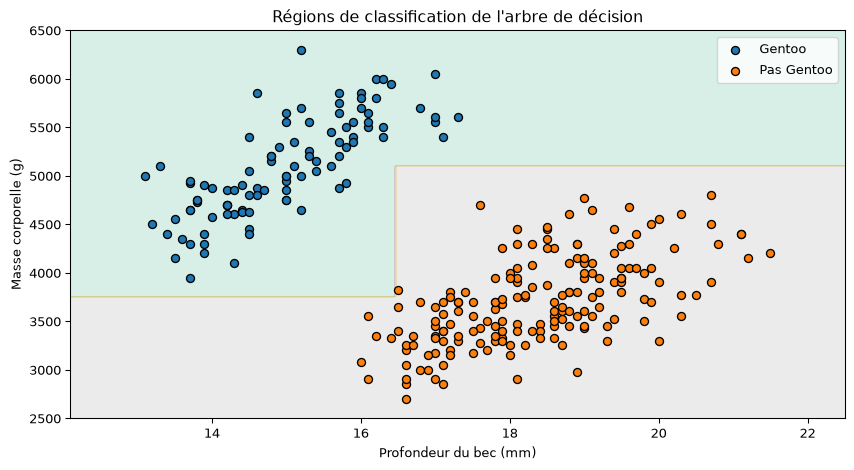

In [12]:
def plot_decision_boundary(X, y, model, feature_names):
    x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x1 = np.linspace(X[:, 1].min() - 200, X[:, 1].max() + 200, 300)
    xx0, xx1 = np.meshgrid(x0, x1)

    grid = np.column_stack([xx0.ravel(), xx1.ravel()])
    predicted = model.predict(grid)
    regions = np.array([
        np.flatnonzero(model.classes_ == label)[0]
        for label in predicted
    ]).reshape(xx0.shape)

    plt.figure(figsize=(9, 5))
    plt.contourf(xx0, xx1, regions, alpha=0.25, cmap="Set2")
    for label in model.classes_:
        selected = y == label
        plt.scatter(
            X[selected, 0],
            X[selected, 1],
            edgecolor="black",
            label=label,
        )
    plt.xlabel("Profondeur du bec (mm)")
    plt.ylabel("Masse corporelle (g)")
    plt.title("Régions de classification de l'arbre de décision")
    plt.legend()
    plt.tight_layout()


plot_decision_boundary(X_train, y_train, tree_model, feature_names)
plt.show()

# Complexité et limites

Dans un nœud contenant $n$ exemples et $D$ attributs, cette
implémentation évalue jusqu’à $D(n-1)$ seuils. Chaque évaluation
parcourt de nouveau les exemples; la recherche d’une division demande
donc approximativement $\mathcal{O}(Dn^2)$ opérations. Les
implémentations de production réutilisent les valeurs triées et des
statistiques suffisantes pour éviter une grande partie de ce travail.

Parmi les autres limites importantes :

- seuls les attributs numériques et les divisions binaires par seuil
  sont pris en charge;
- la recherche gloutonne ne garantit pas un arbre globalement optimal;
- aucune stratégie pour les valeurs manquantes, aucune pondération des
  exemples et aucun élagage ne sont implémentés;
- de petites modifications du jeu d’entraînement peuvent produire un
  arbre différent.

# Expériences suggérées

1.  Modifiez `max_depth`, puis examinez les règles apprises et les
    régions de décision.
2.  Modifiez `min_samples_leaf` et observez quelles petites régions
    disparaissent.
3.  Utilisez les trois espèces plutôt que la cible binaire.
4.  Ajoutez un autre attribut numérique. Le classificateur fonctionnera
    encore, mais les régions de décision ne pourront plus être
    représentées dans une figure bidimensionnelle.
5.  Comparez les prédictions avec celles du `DecisionTreeClassifier` de
    scikit-learn en utilisant `criterion="entropy"`.